In [1]:
import sys
import os

root = "/home/lgreen/projects/low-dimensional-deepnets"  # repo root
sys.path.insert(0, root)

import numpy as np
import pandas as pd
import torch as th
import seaborn as sns
import matplotlib.pyplot as plt
from utils import CDICT_M, CDICT_BSEL, plot_evals


plt.rcParams['figure.figsize'] = [4, 4]
plt.rcParams['figure.dpi'] = 200

sns.set_theme(context='poster', style='ticks', font_scale=2,
              rc={'axes.grid': True, 'grid.color': '.9', 'grid.linewidth': 0.75})


In [2]:
DATASET = "TwoMoons"

In [3]:
p = os.path.join(root, f"inpca_results/{DATASET}/didx_geod_all_progress.p")
df = th.load(p, weights_only=False).reset_index(drop=True)
# Exclude the synthetic geodesic row if present
df = df[df.m != 'geodesic'].reset_index(drop=True)
print("Rows:", len(df), "Cols:", list(df.columns))

Rows: 1848 Cols: ['seed', 'iseed', 'isinit', 'corner', 'aug', 'm', 'opt', 'bs', 'lr', 'wd', 'bsel', 't', 'err', 'verr', 'lam_yh', 'lam_yvh']


In [4]:
# Prefer deriving N_train from your saved label file (single copy)
labels_path = f"/home/lgreen/projects/Online_BS/results/data/labels_{DATASET}.p"  # adjust
labels = th.load(labels_path, weights_only=False)
N_train = int(labels['train'].shape[0])

# Ensure bs is numeric for the computation
def to_int_bs(x):
    try:
        return int(x)
    except Exception:
        return int(float(x))

if 'nepochs' not in df.columns:
    df['bs_int'] = df['bs'].apply(to_int_bs)
    df['nepochs'] = (df['t'] * df['bs_int']) / N_train


In [5]:
# Derive a run identifier; using the filename-based config keys
run_keys = ['m', 'opt', 'bs', 'lr', 'wd', 'seed']
g = df.groupby(run_keys, dropna=False, sort=False)

# End-of-training error (last snapshot per run)
end_err = g['err'].last().rename('end_err').reset_index()
df = df.merge(end_err, on=run_keys, how='left')

# Paper filter (adjust to your runs if models differ)
mask = (df['bs'].astype(str) == '200') & (df['end_err'] < 0.1)
df_f = df[mask].reset_index(drop=True)

print("Filtered rows:", len(df_f))


Filtered rows: 0


In [6]:
# Map architecture names used in the notebook
arch_map = {
    'wr-10-4-8': 'Small ResNet',
    'wr-16-4-64': 'Large ResNet',
    # add your model names here if different, e.g. 'lenet':'LeNet'
}

df_f['Architecture'] = df_f['m'].map(lambda x: arch_map.get(x, x))
df_f['Optimizer'] = df_f['opt']


# Palette: use CDICT_M when available, fallback to seaborn palette
cmap = {arch_map[k]: CDICT_M.get(k, '#1f77b4') for k in arch_map.keys()}
missing = set(df_f['Architecture'].unique()) - set(cmap.keys())
if missing:
    pal = sns.color_palette('Set2', n_colors=len(missing))
    cmap.update(dict(zip(sorted(missing), pal)))


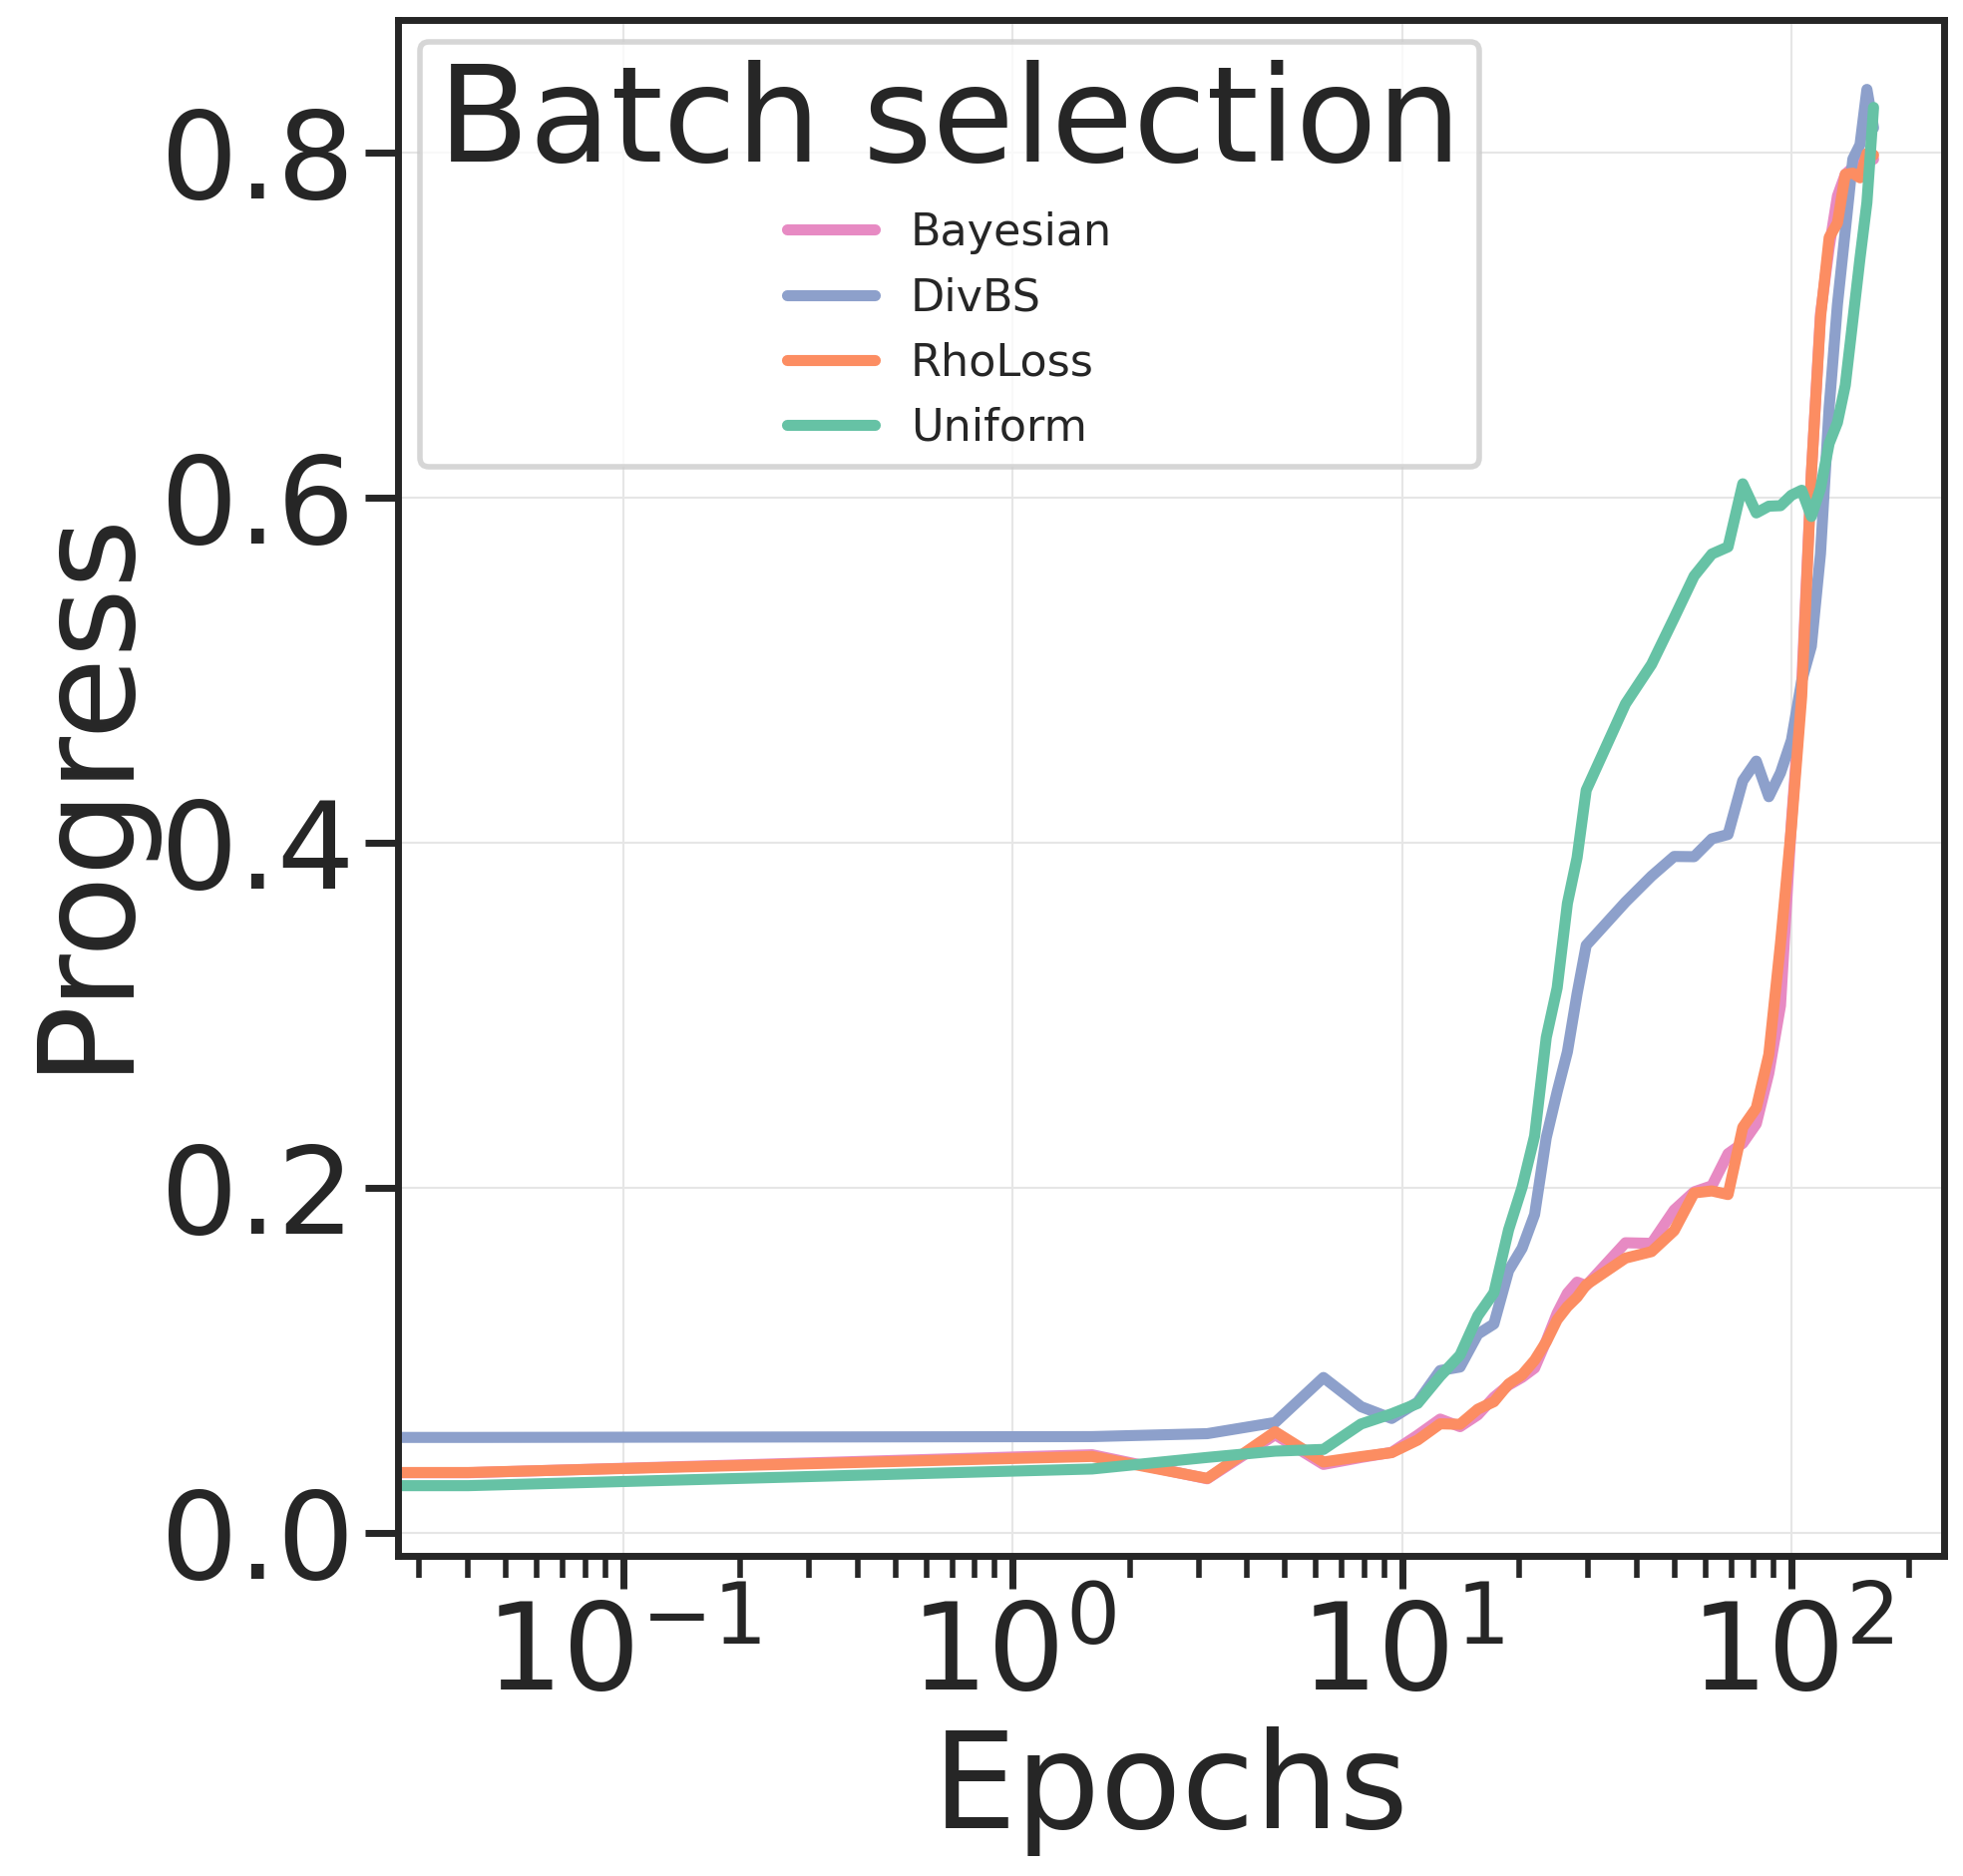

In [7]:
# Alternative view by batch selection (colors fixed via CDICT_BSEL)
if 'bsel' in df.columns:
    df_b = df.copy()
    df_b['BatchMethod'] = df_b['bsel'].astype(str)
    df_b = df_b[df_b['lam_yh'].notna() & df_b['nepochs'].notna()]

    methods = sorted(df_b['BatchMethod'].unique())

    cmap_b = {m: CDICT_BSEL[m] for m in methods if m in CDICT_BSEL}

    missing = [m for m in methods if m not in cmap_b]
    if missing:
        pal = sns.color_palette('Set2', n_colors=len(missing)).as_hex()
        cmap_b.update(dict(zip(missing, pal)))

    f, ax = plt.subplots(figsize=(10, 10))
    sns.lineplot(data=df_b, x='nepochs', y='lam_yh', hue='BatchMethod', palette=cmap_b,
                 estimator='median', errorbar=None, lw=4)
    ax.set(xlabel='Epochs', ylabel='Progress', xscale='log')
    
    plt.legend(fontsize=16, title='Batch selection')

    plt.show()


In [8]:
if 'bsel' in df.columns:
    print('true')

true


In [9]:
print("mask true count:", int(mask.sum()))
print("slice shape:", df_b[mask].shape)
print("Batch methods:", df['bsel'].value_counts())
print("nepochs min/max:", df['nepochs'].min(), df['nepochs'].max())
print("lam_yh non-null:", int(df['lam_yh'].notna().sum()))

mask true count: 0
slice shape: (0, 20)
Batch methods: bsel
Bayesian    462
DivBS       462
RhoLoss     462
Uniform     462
Name: count, dtype: int64
nepochs min/max: 0.0 162.24
lam_yh non-null: 1848


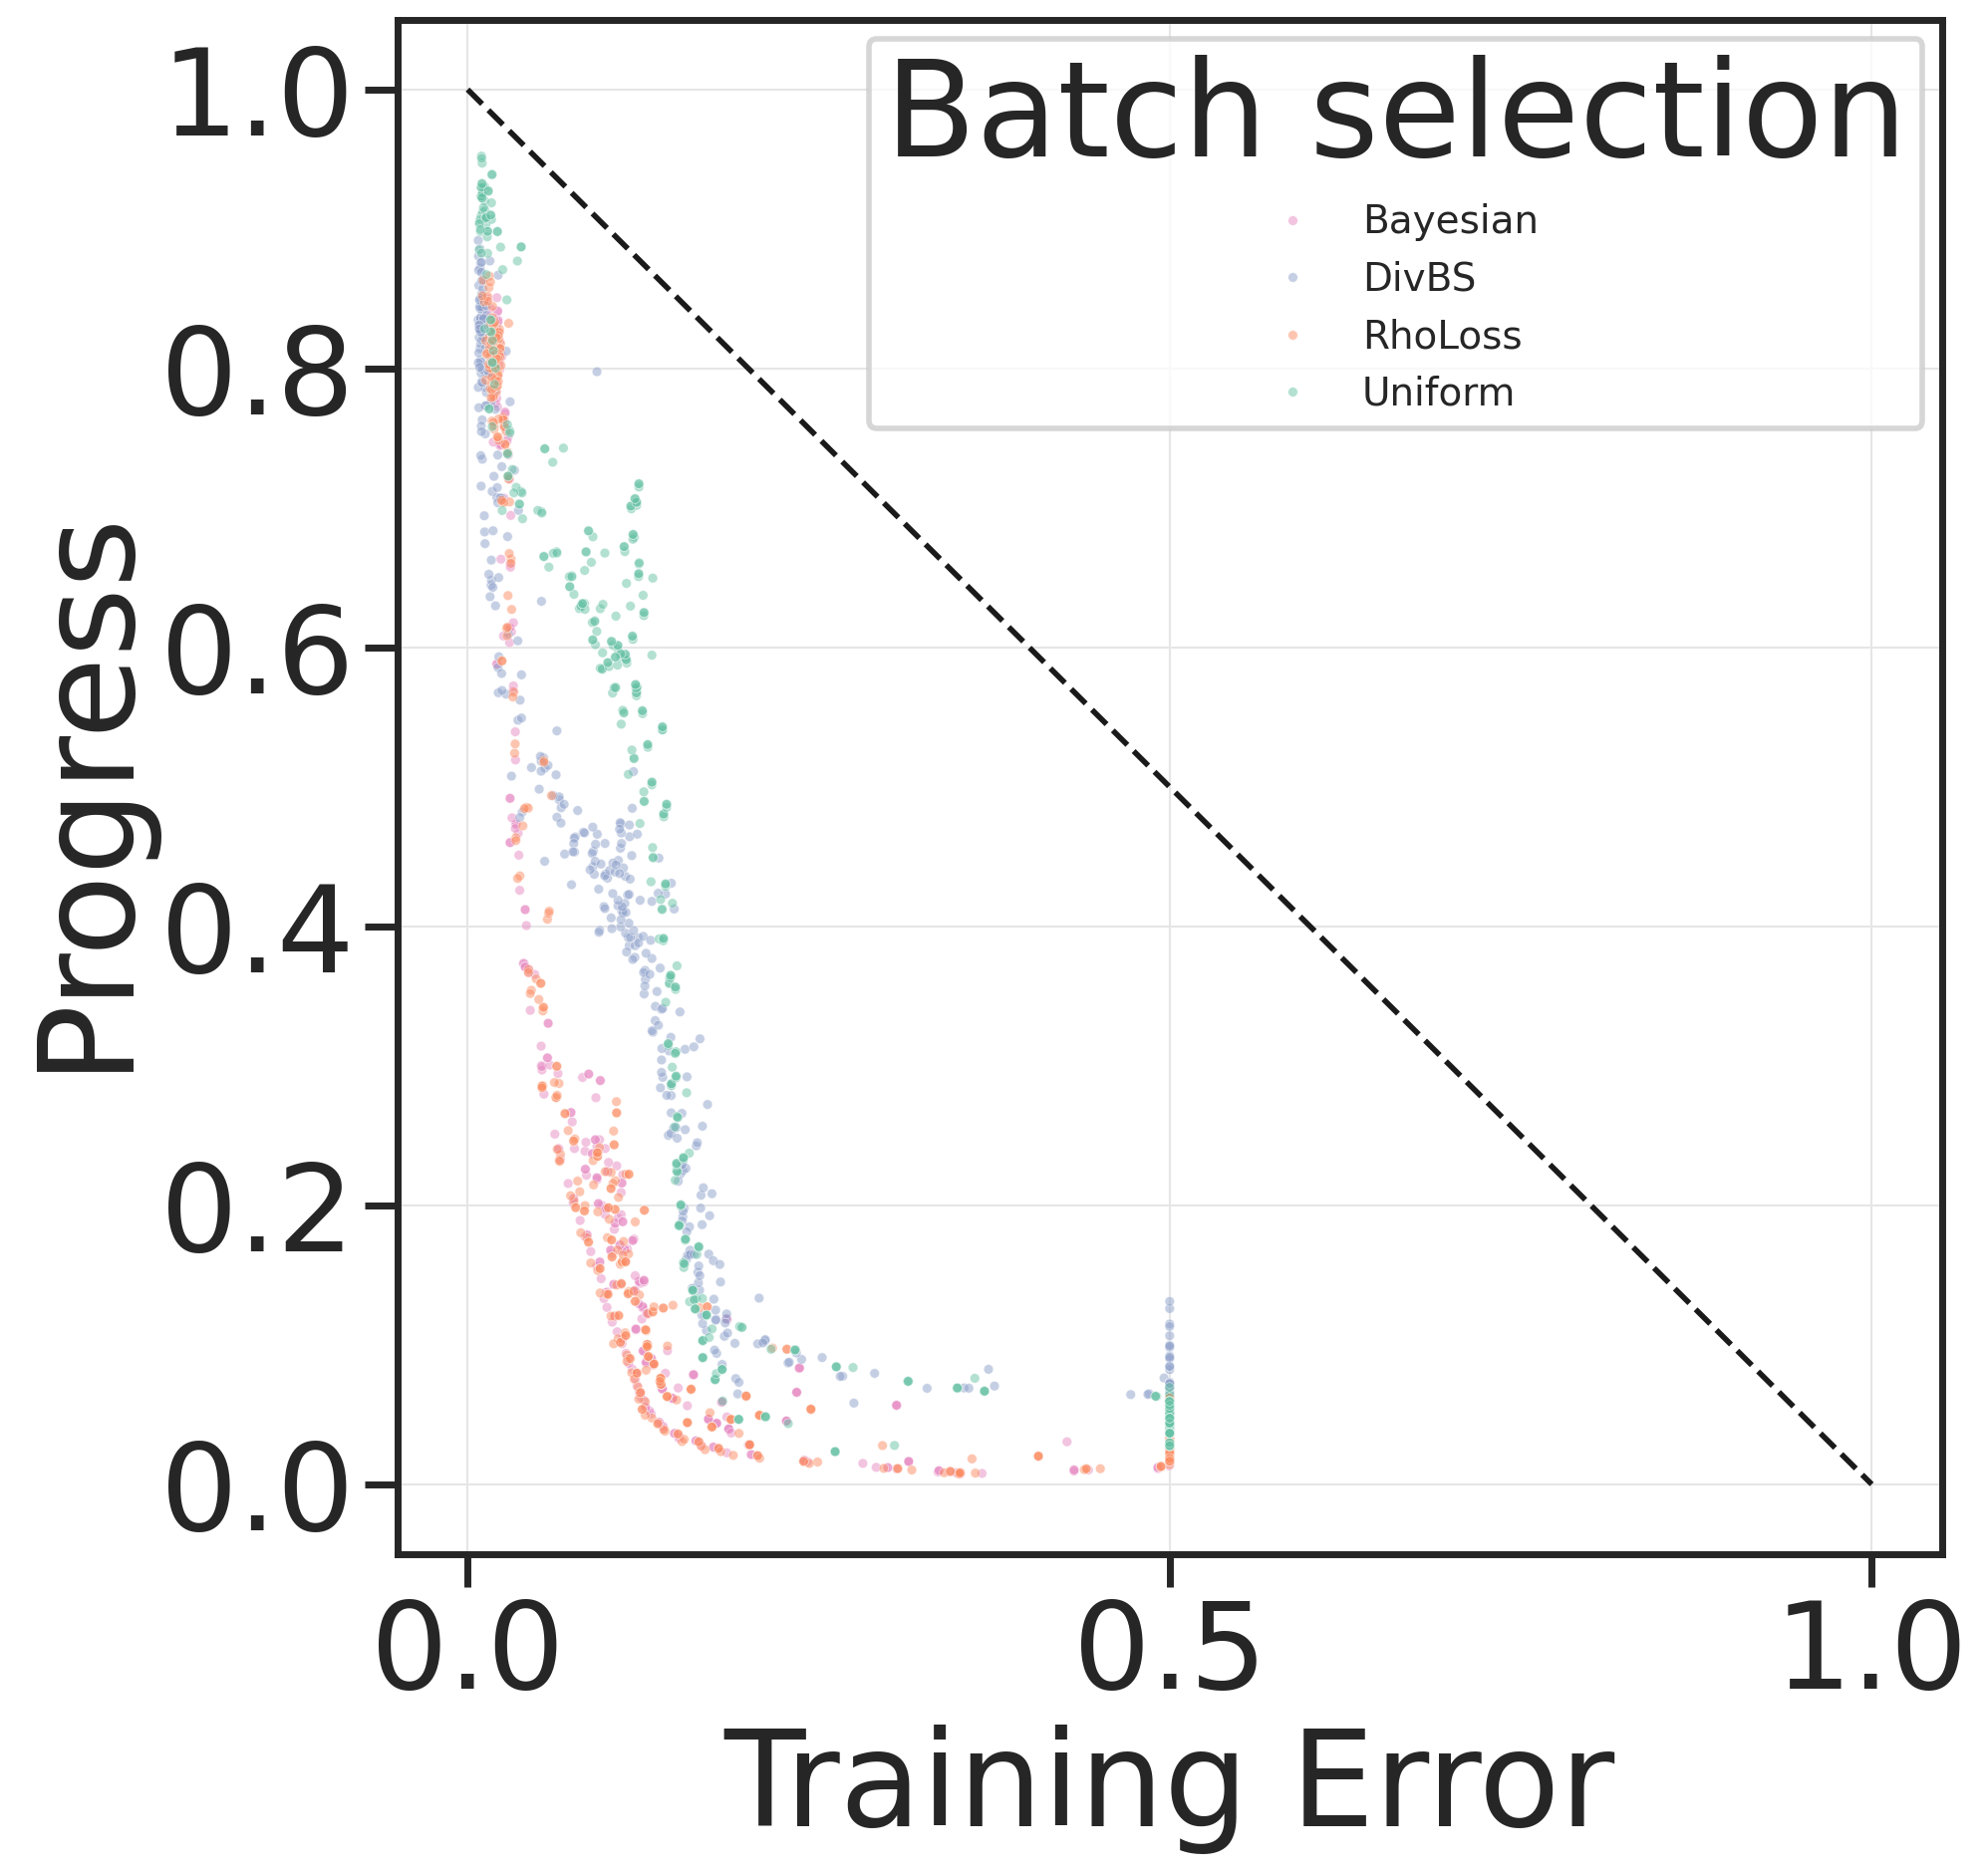

In [10]:
import os
import numpy as np
import torch as th
import seaborn as sns
import matplotlib.pyplot as plt



root = "/home/lgreen/projects/low-dimensional-deepnets"
df = th.load(os.path.join(root, f"inpca_results/{DATASET}/didx_geod_all_progress.p"), weights_only=False).reset_index(drop=True)
df = df[df.m != 'geodesic'].reset_index(drop=True)



# Make sure nepochs exists
labels = th.load(f"/home/lgreen/projects/Online_BS/results/data/labels_{DATASET}.p", weights_only=False)
N_train = int(labels['train'].shape[0])
bs_int = df['bs'].astype(str).astype(int, errors='ignore')
df['nepochs'] = (df['t'] * bs_int) / N_train



# Batch selection method
df['BatchMethod'] = df['bsel'].astype(str)
dfp = df[df['lam_yh'].notna() & df['nepochs'].notna()].reset_index(drop=True)



# Plot 1: Training Error vs Progress, colored by batch selection (colors fixed via CDICT_BSEL)
methods = sorted(dfp['BatchMethod'].unique())

cmap_b = {m: CDICT_BSEL[m] for m in methods if m in CDICT_BSEL}

missing = [m for m in methods if m not in cmap_b]
if missing:
    pal = sns.color_palette('Set2', n_colors=len(missing)).as_hex()
    cmap_b.update(dict(zip(missing, pal)))

f, ax = plt.subplots(figsize=(10, 10))
sns.scatterplot(data=dfp, x='err', y='lam_yh', hue='BatchMethod', palette=cmap_b,
                s=12, alpha=0.5, rasterized=True, ax=ax)
sns.lineplot(x=np.linspace(0, 1, 100), y=np.linspace(0, 1, 100)[::-1],
             ax=ax, linestyle='--', lw=2, color='k', legend=False)
ax.set(xlabel='Training Error', ylabel='Progress')

plt.legend(title='Batch selection', fontsize=14)

plt.show()


seed_for_models: 16
Batch methods in subset: ['Bayesian', 'DivBS', 'RhoLoss', 'Uniform', 'geodesic']


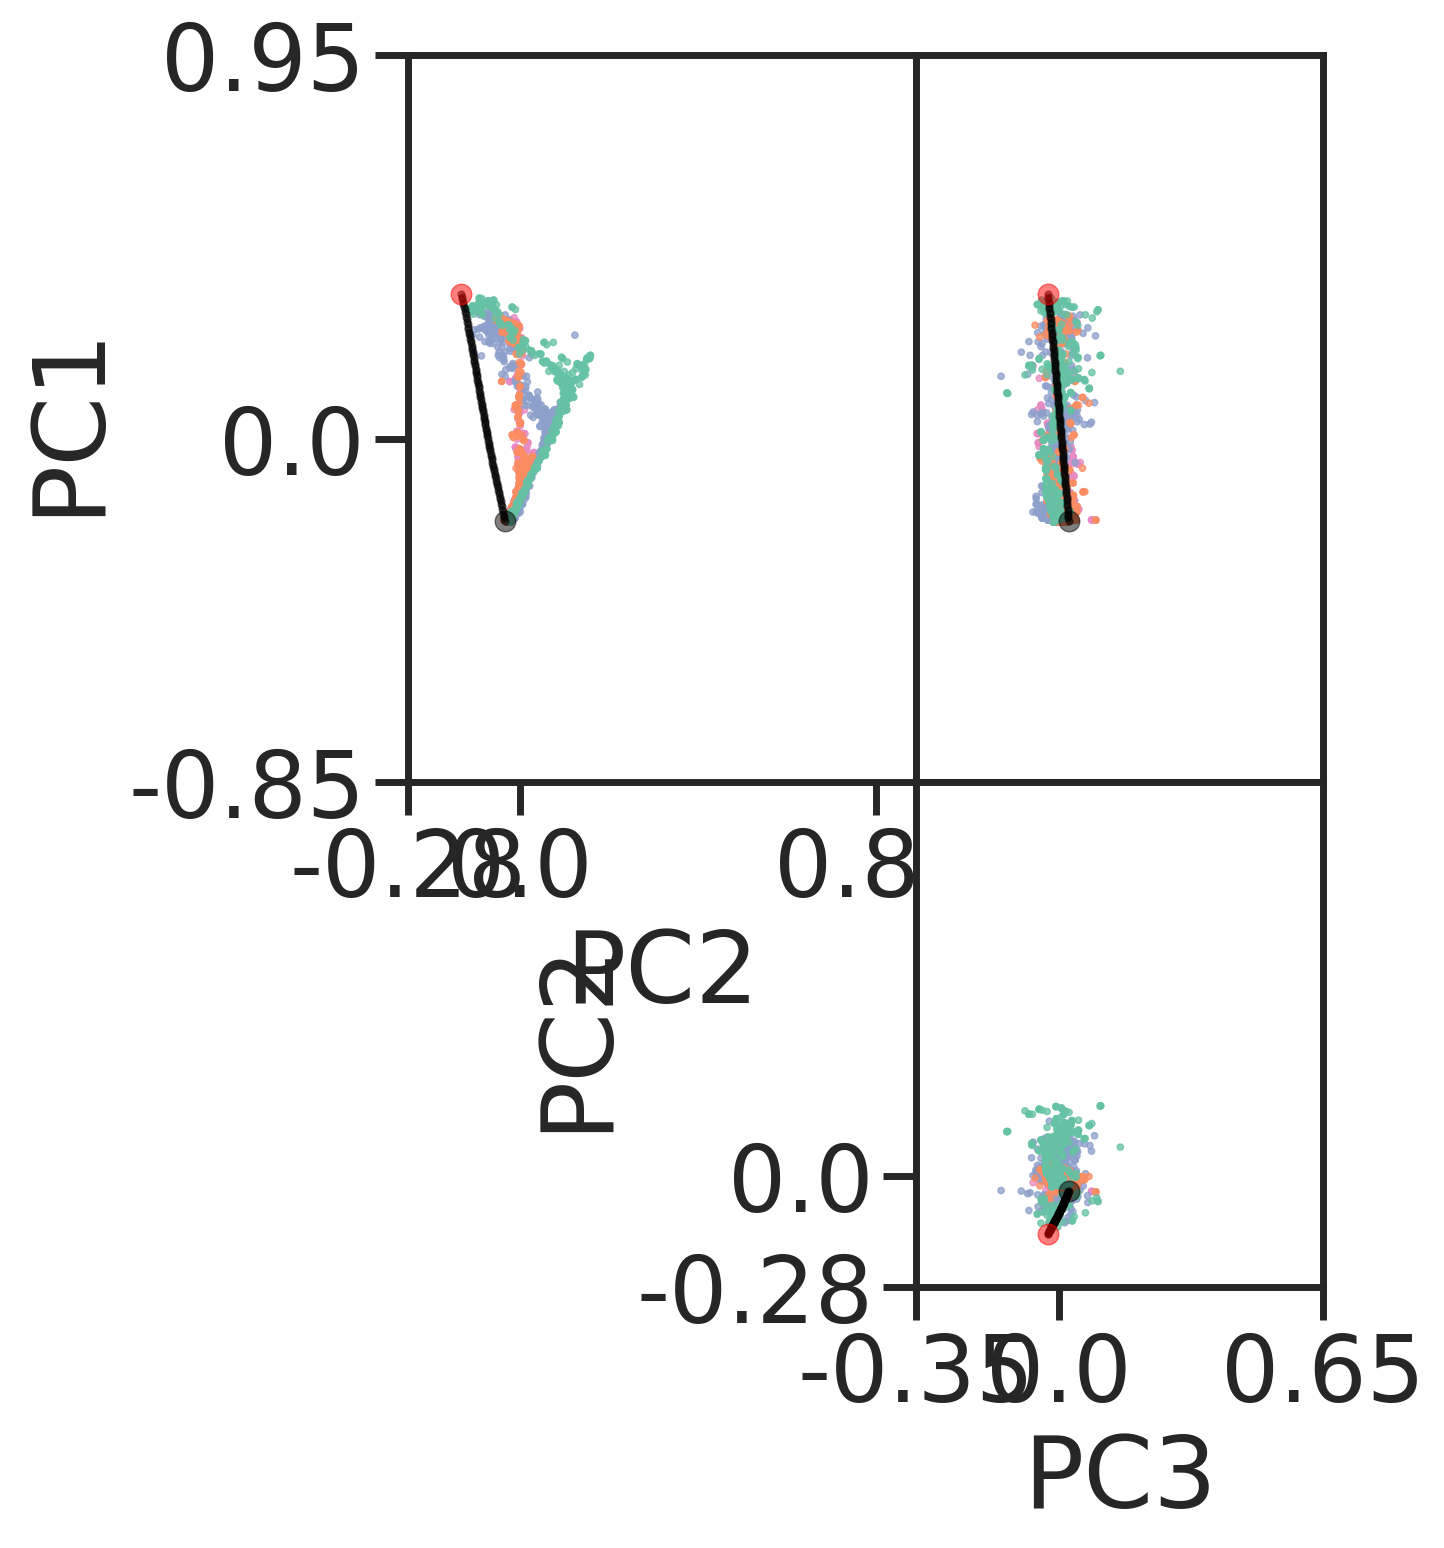

In [11]:
import os
import pandas as pd
import torch as th
import seaborn as sns
import matplotlib.pyplot as plt
from utils.plot import triplot


root = "/home/lgreen/projects/low-dimensional-deepnets"
key = "yh"  # or "yvh"


# 1) Detect the seed used by non-geodesic runs
agg = th.load(os.path.join(root, f"inpca_results/{DATASET}/didx_{key}_all_geod.p"), weights_only=False)
if isinstance(agg, tuple):
    agg = agg[1]
seeds_non_geo = sorted(agg.loc[agg['m'] != 'geodesic', 'seed'].unique())
seed_for_models = int(seeds_non_geo[0]) if seeds_non_geo else 0

print("seed_for_models:", seed_for_models)


# 2) Load the per-seed projection and aligned didx
r = th.load(os.path.join(root, f"inpca_results/{DATASET}/{seed_for_models}/r_{key}_all_geod.p"), weights_only=False)
idx_info = th.load(os.path.join(root, f"inpca_results/{DATASET}/{seed_for_models}/didx_{key}_all_geod.p"), weights_only=False)
didx_s = idx_info[1] if isinstance(idx_info, tuple) else idx_info
didx_s = didx_s.reset_index(drop=True)



# 3) Prepare plotting columns and palette (stable colors via CDICT_BSEL)
if 'BatchMethod' not in didx_s.columns:
    didx_s['BatchMethod'] = didx_s['bsel']

present = list(pd.Series(didx_s['BatchMethod'].astype(str)).unique())
print("Batch methods in subset:", sorted(present))

cdict_used = {k: CDICT_BSEL[k] for k in present if k in CDICT_BSEL}

missing = sorted([k for k in present if k not in cdict_used])
if missing:
    pal = sns.color_palette('Set2', n_colors=len(missing)).as_hex()
    cdict_used.update(dict(zip(missing, pal)))



# 4) Emphasize only the geodesic points; main scatter shows methods
emph = list(didx_s.index[didx_s.get('m', '') == 'geodesic'])

sns.set_theme(context='poster', style='ticks', font_scale=1.5,
              rc={'axes.grid': True, 'grid.color': '.9', 'grid.linewidth': 0.75})

f, gs = triplot(
    didx_s,
    r,
    emph={"geodesic": emph, "p0": emph[:1], "p*": emph[-1:]},
    empsize={"geodesic": 6, "p0": 55, "p*": 55, "ref": 8},
    empcolor={"geodesic": "black", "p0": "black", "p*": "red", "ref": "red"},
    grid_ratio=[3.6, 2.5, 2.0],
    grid_size=0.25,
    centers=[0.05, 0.35, 0.15],
    ax_label=True,
    ckey="BatchMethod",
    cdict=cdict_used,
    discrete_c=True,
)

plt.show()


KeyError: 'es'

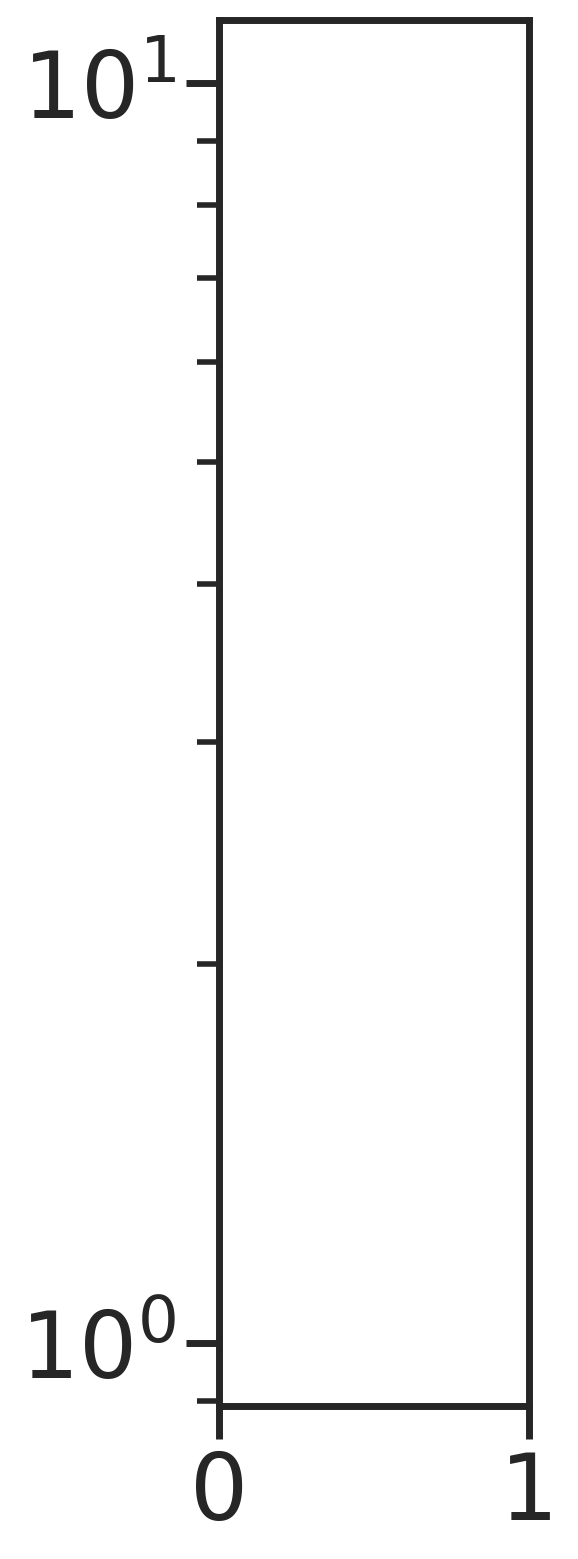

In [12]:
sns.set_theme(context='poster', style='ticks', font_scale=1.5,
              rc={'axes.grid': True, 'grid.color': '.9', 'grid.linewidth': 0.75})
r = th.load(f"{root}/inpca_results/{DATASET}/{seed_for_models}/r_{key}_all_geod_all.p", weights_only=False)

f = plot_evals(r)
